# Task 2: Deep Learning Model - Binary Classification

**Project**: Policy Optimization for Financial Decision-Making  
**Author**: Shreyansh Singh 
**Date**: October 2025

---

## Objective
Build a neural network classifier to predict loan defaults:
1. Load preprocessed data from Task 1
2. Build PyTorch neural network architecture
3. Train model with early stopping
4. Evaluate using AUC-ROC and F1-Score
5. Analyze model performance
6. Save trained model for Task 4

---

## Model Goal
**Predict**: Will this loan applicant default? (Binary: 0=Paid, 1=Default)  
**Metrics**: AUC-ROC (primary), F1-Score (secondary)  
**Why**: Measure classification accuracy, not financial outcome

In [207]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve
)
import joblib
from tqdm import tqdm
import time

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}" if hasattr(torch.backends, 'mps') else "MPS: Not available (requires PyTorch 1.12+)")

Libraries imported successfully!
PyTorch version: 2.5.1
CUDA available: False
MPS available: True


In [208]:
PROJECT_ROOT = Path('.').absolute().parent
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
FIGURES_DIR = PROJECT_ROOT / 'figures'

MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("Directories ready!")
print(f"Data: {DATA_DIR}")
print(f"Models: {MODELS_DIR}")

Directories ready!
Data: /Users/shreyanshsingh/Downloads/Shodh AI/Projects/loan-policy-optimization/data/processed
Models: /Users/shreyanshsingh/Downloads/Shodh AI/Projects/loan-policy-optimization/models


In [209]:
# Setup device
if torch.backends.mps.is_available() and hasattr(torch.backends, 'mps'):
    device = torch.device("mps")  # Apple Silicon GPU
    print("Using Apple Silicon MPS (Metal Performance Shaders) - GPU acceleration enabled!")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU (no GPU detected)")

print(f"\nDevice: {device}")

Using Apple Silicon MPS (Metal Performance Shaders) - GPU acceleration enabled!

Device: mps


## 1. Load Preprocessed Data

In [211]:
# Load scaled data (for neural networks)
print("Loading preprocessed data...")

X_train = pd.read_csv(DATA_DIR / 'X_train_scaled.csv')
X_val = pd.read_csv(DATA_DIR / 'X_val_scaled.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test_scaled.csv')

y_train = pd.read_csv(DATA_DIR / 'y_train.csv').values.ravel()
y_val = pd.read_csv(DATA_DIR / 'y_val.csv').values.ravel()
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').values.ravel()

print(f"\nData loaded successfully!")
print(f"Train: {X_train.shape} | {len(y_train)} labels")
print(f"Val:   {X_val.shape} | {len(y_val)} labels")
print(f"Test:  {X_test.shape} | {len(y_test)} labels")

# Verify class balance
print(f"\nClass distribution:")
print(f"Train: {(y_train == 1).sum() / len(y_train) * 100:.1f}% defaults")
print(f"Val:   {(y_val == 1).sum() / len(y_val) * 100:.1f}% defaults")
print(f"Test:  {(y_test == 1).sum() / len(y_test) * 100:.1f}% defaults")

Loading preprocessed data...

Data loaded successfully!
Train: (489981, 21) | 489981 labels
Val:   (105018, 21) | 105018 labels
Test:  (105000, 21) | 105000 labels

Class distribution:
Train: 21.5% defaults
Val:   21.5% defaults
Test:  21.5% defaults


In [212]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.FloatTensor(y_train)

X_val_tensor = torch.FloatTensor(X_val.values)
y_val_tensor = torch.FloatTensor(y_val)

X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test)

print("Converted to PyTorch tensors")
print(f"Train tensor shape: {X_train_tensor.shape}")
print(f"Device will be: {device}")

Converted to PyTorch tensors
Train tensor shape: torch.Size([489981, 21])
Device will be: mps


In [213]:
# Create DataLoaders for efficient batching
BATCH_SIZE = 512  

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders created")
print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

DataLoaders created
Batch size: 512
Train batches: 957
Val batches: 206
Test batches: 206


## 2. Define Neural Network Architecture

In [215]:
class LoanDefaultClassifier(nn.Module):
    """
    Deep Neural Network for Loan Default Prediction
    
    Architecture:
    - Input Layer: 21 features
    - Hidden Layer 1: 128 neurons + ReLU + Dropout(0.3)
    - Hidden Layer 2: 64 neurons + ReLU + Dropout(0.3)
    - Hidden Layer 3: 32 neurons + ReLU + Dropout(0.2)
    - Output Layer: 1 neuron + Sigmoid (binary classification)
    """
    
    def __init__(self, input_dim):
        super(LoanDefaultClassifier, self).__init__()
        
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Layer 3
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Output Layer
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

# Initialize model
input_dim = X_train.shape[1]
model = LoanDefaultClassifier(input_dim)
model = model.to(device)


print(f"\nModel Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Model Architecture:
LoanDefaultClassifier(
  (network): Sequential(
    (0): Linear(in_features=21, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Total parameters: 13,633
Trainable parameters: 13,633


## 3. Training Setup

In [217]:
# Loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True
)


print(f"Loss function: Binary Cross-Entropy")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Scheduler: ReduceLROnPlateau (patience=3)")

Loss function: Binary Cross-Entropy
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau (patience=3)


In [218]:
# Training and evaluation functions
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train model for one epoch
    """
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device).unsqueeze(1)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * batch_X.size(0)
        all_preds.extend(outputs.detach().cpu().numpy())
        all_labels.extend(batch_y.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_auc = roc_auc_score(all_labels, all_preds)
    
    return epoch_loss, epoch_auc


def evaluate(model, data_loader, criterion, device):
    """
    Evaluate model on validation/test set
    """
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device).unsqueeze(1)
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            running_loss += loss.item() * batch_X.size(0)
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_auc = roc_auc_score(all_labels, all_preds)
    
    # Calculating F1-Score at threshold 0.5
    preds_binary = (np.array(all_preds) > 0.5).astype(int)
    epoch_f1 = f1_score(all_labels, preds_binary)
    
    return epoch_loss, epoch_auc, epoch_f1, all_preds, all_labels

print("Training functions defined")

Training functions defined


## 4. Train Model

In [220]:
# Training configuration
NUM_EPOCHS = 30
PATIENCE = 7  # Early stopping patience
best_val_auc = 0.0
patience_counter = 0

# History tracking
history = {
    'train_loss': [],
    'train_auc': [],
    'val_loss': [],
    'val_auc': [],
    'val_f1': []
}

print("=" * 80)
print("TRAINING DEEP LEARNING MODEL")
print("=" * 80)
print(f"Max epochs: {NUM_EPOCHS}")
print(f"Early stopping patience: {PATIENCE}")
print(f"Device: {device}")
print("=" * 80)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    
    # Train
    train_loss, train_auc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_auc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step(val_auc)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['val_f1'].append(val_f1)
    
    epoch_time = time.time() - epoch_start
    
    # Print progress
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} | Val F1: {val_f1:.4f} | "
          f"Time: {epoch_time:.1f}s")
    
    # Early stopping check
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), MODELS_DIR / 'dl_model_best.pt')
        print(f"   New best model! AUC: {best_val_auc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️  Early stopping triggered! No improvement for {PATIENCE} epochs.")
            break

total_time = time.time() - start_time
print("\n" + "=" * 80)
print(f"For Training")
print(f"Total time: {total_time/60:.1f} minutes")
print(f"Best validation AUC: {best_val_auc:.4f}")
print("=" * 80)

TRAINING DEEP LEARNING MODEL
Max epochs: 30
Early stopping patience: 7
Device: mps
Epoch 01/30 | Train Loss: 0.4936 | Train AUC: 0.6767 | Val Loss: 0.4728 | Val AUC: 0.7099 | Val F1: 0.1878 | Time: 8.3s
   New best model! AUC: 0.7099
Epoch 02/30 | Train Loss: 0.4764 | Train AUC: 0.7023 | Val Loss: 0.4719 | Val AUC: 0.7114 | Val F1: 0.1548 | Time: 6.8s
   New best model! AUC: 0.7114
Epoch 03/30 | Train Loss: 0.4748 | Train AUC: 0.7055 | Val Loss: 0.4709 | Val AUC: 0.7126 | Val F1: 0.1569 | Time: 6.5s
   New best model! AUC: 0.7126
Epoch 04/30 | Train Loss: 0.4738 | Train AUC: 0.7073 | Val Loss: 0.4707 | Val AUC: 0.7130 | Val F1: 0.1426 | Time: 6.5s
   New best model! AUC: 0.7130
Epoch 05/30 | Train Loss: 0.4728 | Train AUC: 0.7091 | Val Loss: 0.4705 | Val AUC: 0.7135 | Val F1: 0.1208 | Time: 6.6s
   New best model! AUC: 0.7135
Epoch 06/30 | Train Loss: 0.4726 | Train AUC: 0.7097 | Val Loss: 0.4701 | Val AUC: 0.7141 | Val F1: 0.1326 | Time: 6.6s
   New best model! AUC: 0.7141
Epoch 07/30

## 5. Training History Visualization

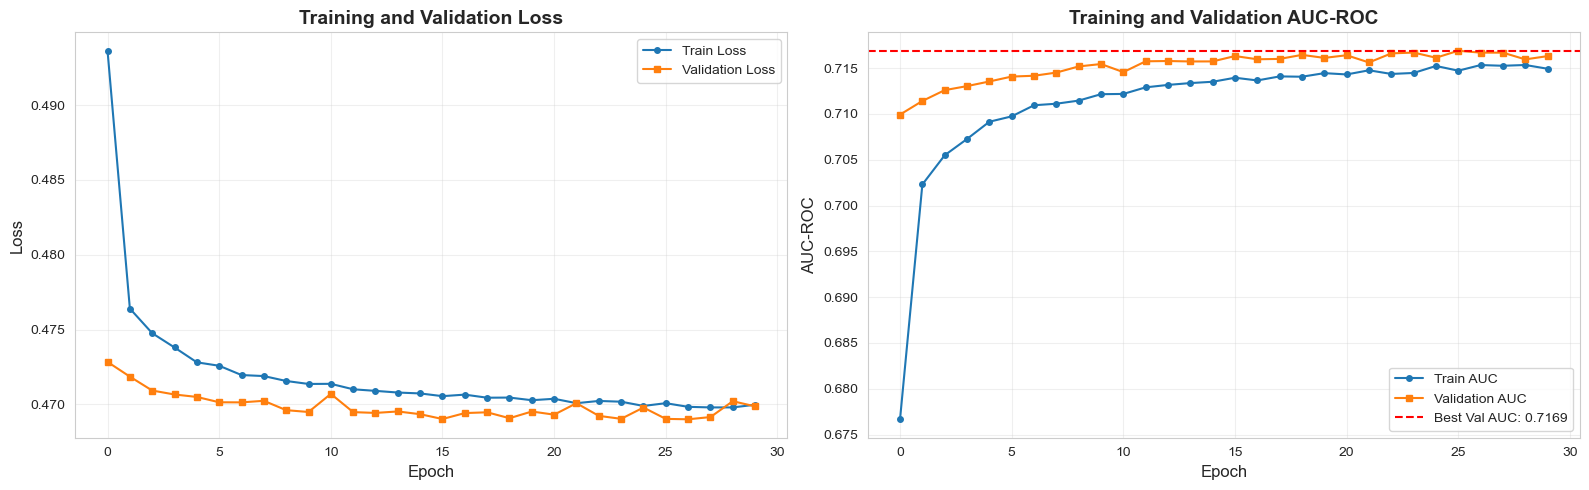

Training history plot saved


In [222]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Validation Loss', marker='s', markersize=4)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUC plot
axes[1].plot(history['train_auc'], label='Train AUC', marker='o', markersize=4)
axes[1].plot(history['val_auc'], label='Validation AUC', marker='s', markersize=4)
axes[1].axhline(y=best_val_auc, color='r', linestyle='--', label=f'Best Val AUC: {best_val_auc:.4f}')
axes[1].set_title('Training and Validation AUC-ROC', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('AUC-ROC', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training history plot saved")

## 6. Load Best Model and Evaluate on Test Set

In [224]:
# Load best model
model.load_state_dict(torch.load(MODELS_DIR / 'dl_model_best.pt'))
model.eval()
print("Best model loaded")

# Evaluate on test set
test_loss, test_auc, test_f1, test_probs, test_labels = evaluate(
    model, test_loader, criterion, device
)

# Convert predictions to binary
test_probs = np.array(test_probs).ravel()
test_preds = (test_probs > 0.5).astype(int)
test_labels = np.array(test_labels).ravel()

# Calculate additional metrics
test_accuracy = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds)
test_recall = recall_score(test_labels, test_preds)

print("\n" + "=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)
print(f"AUC-ROC:   {test_auc:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print("=" * 60)

Best model loaded

TEST SET PERFORMANCE
AUC-ROC:   0.7175
F1-Score:  0.1080
Accuracy:  0.7893
Precision: 0.5972
Recall:    0.0594


## 7. Confusion Matrix

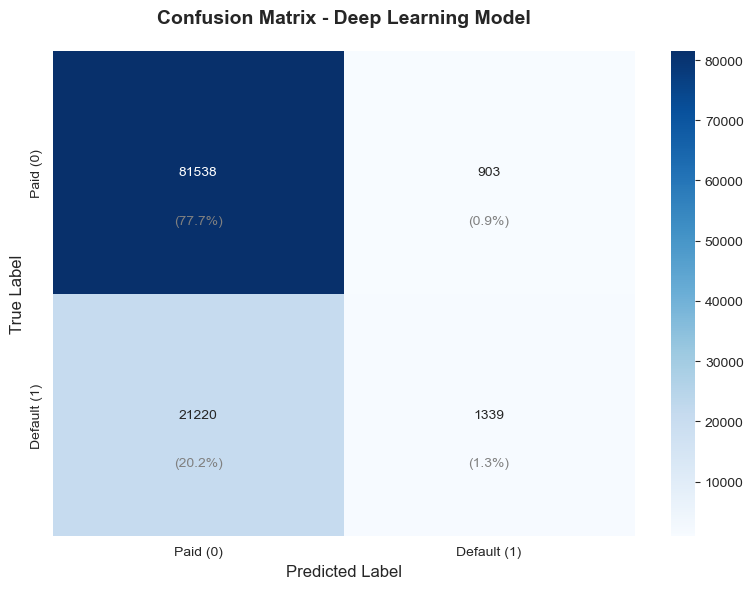

Confusion matrix saved

Confusion Matrix Breakdown:
True Negatives (Correctly predicted Paid):    81,538
False Positives (Incorrectly predicted Default): 903
False Negatives (Incorrectly predicted Paid):    21,220
True Positives (Correctly predicted Default):  1,339


In [226]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Paid (0)', 'Default (1)'],
            yticklabels=['Paid (0)', 'Default (1)'])
plt.title('Confusion Matrix - Deep Learning Model', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

# Add percentages
cm_percent = cm / cm.sum()
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.7, f'({cm_percent[i,j]*100:.1f}%)', 
                ha='center', va='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved")

# Extract values
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives (Correctly predicted Paid):    {tn:,}")
print(f"False Positives (Incorrectly predicted Default): {fp:,}")
print(f"False Negatives (Incorrectly predicted Paid):    {fn:,}")
print(f"True Positives (Correctly predicted Default):  {tp:,}")

## 8. ROC Curve

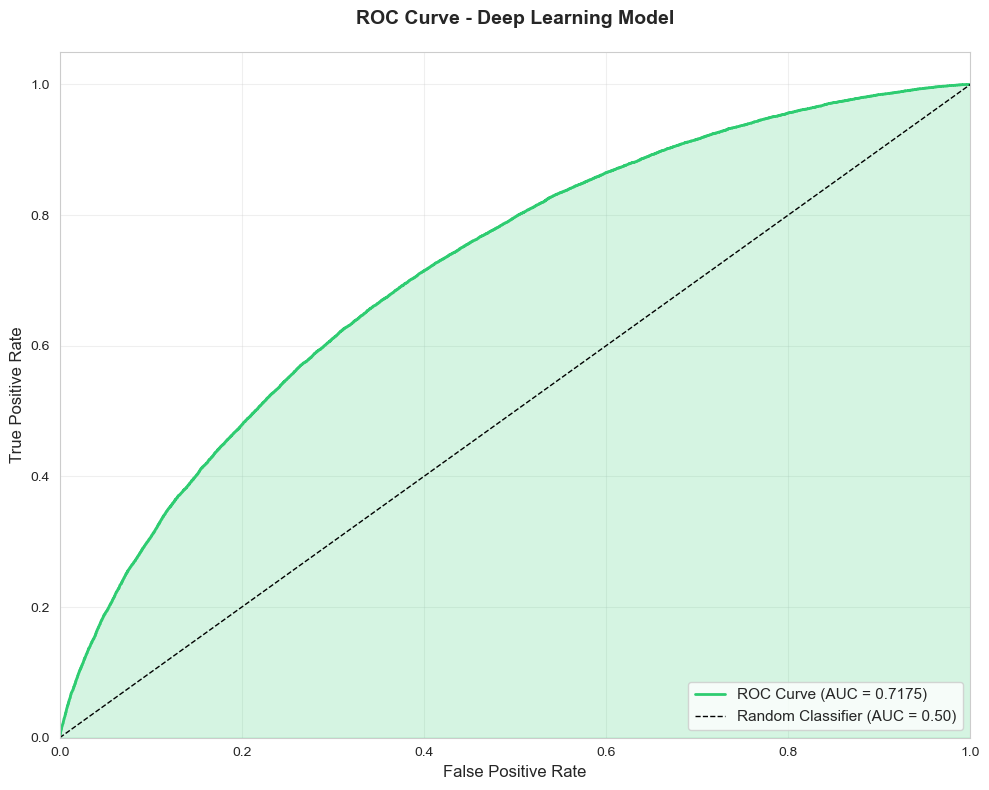

ROC curve saved


In [228]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='#2ecc71', linewidth=2, label=f'ROC Curve (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.2, color='#2ecc71')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Deep Learning Model', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("ROC curve saved")

## 9. Threshold Analysis

In [230]:
# Find optimal threshold using Youden's J statistic
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_fpr = fpr[optimal_idx]

print(f"Optimal Threshold Analysis:")
print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"TPR at optimal: {optimal_tpr:.4f}")
print(f"FPR at optimal: {optimal_fpr:.4f}")

# Try different thresholds
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, optimal_threshold]
threshold_results = []

for thresh in thresholds_to_test:
    preds_at_thresh = (test_probs >= thresh).astype(int)
    f1 = f1_score(test_labels, preds_at_thresh)
    precision = precision_score(test_labels, preds_at_thresh)
    recall = recall_score(test_labels, preds_at_thresh)
    threshold_results.append({
        'Threshold': thresh,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall
    })

threshold_df = pd.DataFrame(threshold_results)
print(f"\nPerformance at Different Thresholds:")
print(threshold_df.to_string(index=False))

Optimal Threshold Analysis:
Optimal threshold: 0.1997
TPR at optimal: 0.6911
FPR at optimal: 0.3748

Performance at Different Thresholds:
 Threshold  F1-Score  Precision   Recall
  0.300000  0.420481   0.413812 0.427368
  0.400000  0.292617   0.499198 0.206968
  0.500000  0.107980   0.597235 0.059355
  0.600000  0.016899   0.684397 0.008555
  0.199689  0.451576   0.335355 0.691077


## 10. Classification Report

In [232]:
# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(test_labels, test_preds, 
                          target_names=['Paid (0)', 'Default (1)'],
                          digits=4))


Detailed Classification Report:
              precision    recall  f1-score   support

    Paid (0)     0.7935    0.9890    0.8805     82441
 Default (1)     0.5972    0.0594    0.1080     22559

    accuracy                         0.7893    105000
   macro avg     0.6954    0.5242    0.4943    105000
weighted avg     0.7513    0.7893    0.7146    105000



## 11. Save Model and Results

In [234]:
# Save final model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'input_dim': input_dim,
    'test_auc': test_auc,
    'test_f1': test_f1,
    'best_val_auc': best_val_auc,
    'history': history
}, MODELS_DIR / 'dl_model_final.pt')

print("Model saved to:", MODELS_DIR / 'dl_model_final.pt')

# Save predictions for Task 4 comparison
predictions_df = pd.DataFrame({
    'true_label': test_labels,
    'predicted_prob': test_probs,
    'predicted_class': test_preds
})
predictions_df.to_csv(MODELS_DIR / 'dl_predictions.csv', index=False)
print("Predictions saved to:", MODELS_DIR / 'dl_predictions.csv')

Model saved to: /Users/shreyanshsingh/Downloads/Shodh AI/Projects/loan-policy-optimization/models/dl_model_final.pt
Predictions saved to: /Users/shreyanshsingh/Downloads/Shodh AI/Projects/loan-policy-optimization/models/dl_predictions.csv


In [235]:
# Save summary results (FIXED VERSION)
results_summary = {
    'model_type': 'Deep Learning - Neural Network',
    'architecture': '21 -> 128 -> 64 -> 32 -> 1',
    'total_parameters': int(total_params),  # Convert to int
    'training_time_minutes': float(round(total_time / 60, 2)),  # Convert to float
    'epochs_trained': int(len(history['train_loss'])),
    'best_val_auc': float(round(best_val_auc, 4)),  # Convert to float
    'test_metrics': {
        'auc_roc': float(round(test_auc, 4)),  # Convert to float
        'f1_score': float(round(test_f1, 4)),  # Convert to float
        'accuracy': float(round(test_accuracy, 4)),  # Convert to float
        'precision': float(round(test_precision, 4)),  # Convert to float
        'recall': float(round(test_recall, 4))  # Convert to float
    },
    'confusion_matrix': {
        'true_negatives': int(tn),
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'true_positives': int(tp)
    },
    'optimal_threshold': float(round(optimal_threshold, 4)),  # Convert to float
    'device_used': str(device)
}

with open(MODELS_DIR / 'dl_model_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("Summary saved to:", MODELS_DIR / 'dl_model_summary.json')

Summary saved to: /Users/shreyanshsingh/Downloads/Shodh AI/Projects/loan-policy-optimization/models/dl_model_summary.json


## 12. Task 2 Summary

In [237]:
print("\n" + "="*80)
print("TASK 2 COMPLETE - DEEP LEARNING MODEL")
print("="*80)
print(f"\nModel Architecture: 21 → 128 → 64 → 32 → 1")
print(f"Total Parameters: {total_params:,}")
print(f"Training Time: {total_time/60:.1f} minutes")
print(f"Device Used: {device}")
print(f"\nFINAL TEST PERFORMANCE:")
print(f"   AUC-ROC:   {test_auc:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")
print(f"   Accuracy:  {test_accuracy:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"\nFiles Created:")
print(f"   • models/dl_model_final.pt")
print(f"   • models/dl_predictions.csv")
print(f"   • models/dl_model_summary.json")
print(f"   • figures/dl_training_history.png")
print(f"   • figures/dl_confusion_matrix.png")
print(f"   • figures/dl_roc_curve.png")
print(f"\nKEY INSIGHTS:")
print(f"   • Model predicts loan defaults with {test_auc:.1%} AUC")
print(f"   • Correctly identifies {test_recall:.1%} of actual defaults (Recall)")
print(f"   • {test_precision:.1%} of predicted defaults are correct (Precision)")
print(f"   • Optimal threshold: {optimal_threshold:.4f} (vs default 0.5)")
print("\n" + "="*80)



TASK 2 COMPLETE - DEEP LEARNING MODEL

Model Architecture: 21 → 128 → 64 → 32 → 1
Total Parameters: 13,633
Training Time: 3.4 minutes
Device Used: mps

FINAL TEST PERFORMANCE:
   AUC-ROC:   0.7175
   F1-Score:  0.1080
   Accuracy:  0.7893
   Precision: 0.5972
   Recall:    0.0594

Files Created:
   • models/dl_model_final.pt
   • models/dl_predictions.csv
   • models/dl_model_summary.json
   • figures/dl_training_history.png
   • figures/dl_confusion_matrix.png
   • figures/dl_roc_curve.png

KEY INSIGHTS:
   • Model predicts loan defaults with 71.7% AUC
   • Correctly identifies 5.9% of actual defaults (Recall)
   • 59.7% of predicted defaults are correct (Precision)
   • Optimal threshold: 0.1997 (vs default 0.5)

